# Yields

### Data

Use the data file `data/treasury_quotes_2025-04-30.xlsx`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

filepath = 'data/treasury_quotes_2025-04-30.xlsx'
selected = pd.read_excel(filepath, sheet_name='selected quotes').set_index('KYTREASNO')

print(selected.shape)
selected.head()

(20, 14)


,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size
KYTREASNO,,,,,,,,,,,,,,
208129,note,2025-04-30,2023-10-31,2025-10-31,0.503765,0.0,5.000,100.402344,100.412129,100.407236,0.0,100.407236,0.041371,46713000000
208213,note,2025-04-30,2024-04-30,2026-04-30,0.999316,0.0,4.875,100.931250,100.950766,100.941008,0.0,100.941008,0.039086,69310000000
208302,note,2025-04-30,2024-10-31,2026-10-31,1.503080,0.0,4.125,100.570312,100.593750,100.582031,0.0,100.582031,0.037147,70157000000
208385,note,2025-04-30,2025-04-30,2027-04-30,1.998631,0.0,3.750,100.292969,100.296875,100.294922,0.0,100.294922,0.035981,73725000000
207960,note,2025-04-30,2022-10-31,2027-10-31,2.502396,0.0,4.125,101.269531,101.296875,101.283203,0.0,101.283203,0.035803,43000000000


# 1 YTM and Price

The problems in this section ask you to calculate the **yield-to-maturity (YTM)** of various bonds.

You will need to use a nonlinear solver to solve for the YTM.

For any given bond, YTM ($y$) solves...

$$p = \sum_{i=1}^{2n}\frac{Fc/2}{(1+y/2)^i} + \frac{F}{(1+y/2)^{2n}}$$

where
* $p$ is the bond's price.
* $n$ is the number of years to maturity
* $c$ is the coupon rate (a percentage)
* $F$ is the face value. Use $F=100$

#### Solving for YTM
Consider using `fsolve` to solve the yield implicitly from the nonlinear equation. This function is imported with...

`from scipy.optimize import fsolve`

### 1.1

Consider a semiannual bond with the following stylized parameters:
* time-to-maturity of 30 years
* coupon rate: 3%
* Face value of 100

1. Assume the YTM is 5%. Calculate the price.
1. Assume the price is 87. Calculate the YTM.

In [2]:
# price of a semiannual coupon bond
def bond_price(y, n, c, F=100):
    periods = int(round(2 * n))
    price = sum(F * c / 2 / (1 + y / 2)**i for i in range(1, periods + 1))
    price += F / (1 + y / 2)**periods
    return price

# solve for the ytm that matches a given price
def solve_ytm(p, n, c, F=100, guess=0.04):
    return fsolve(lambda y: bond_price(y, n, c, F) - p, guess)[0]

price_1 = bond_price(0.05, 30, 0.03)
ytm_2 = solve_ytm(87, 30, 0.03)

print(f'1. price at 5% ytm: {price_1:.4f}')
print(f'2. ytm at price 87: {ytm_2:.4%}')

1. price at 5% ytm: 69.0913
2. ytm at price 87: 3.7231%


### 1.2

### Data
Use the data in the `selected quotes` tab.
* It gives treasury bond data for various maturities, spaced roughly six months apart.
* Feel free to approximate the time-to-maturity to be exactly semiannually if that is easier for the problem below.
* Use the `price` column for the price data in the YTM formula. (No need to worry about "dirty" price, bid, ask, nor accrued interest.)

1. Calculate the yield-to-maturity for each issue. How close are your calculations to the provided column `ytm`?

1. Plot the time-to-maturity (TTM) against the calculated YTM.

In [3]:
# ytm for each issue, rounding ttm to whole semiannual periods
selected['calc ytm'] = [
    solve_ytm(row['price'], round(2 * row['ttm']) / 2, row['cpn rate'] / 100)
    for _, row in selected.iterrows()
]

comparison = selected[['ttm', 'cpn rate', 'price', 'ytm', 'calc ytm']].copy()
comparison['diff (bps)'] = (comparison['calc ytm'] - comparison['ytm']) * 1e4

print(f"average absolute difference: {comparison['diff (bps)'].abs().mean():.2f} bps")
comparison.round(4)

average absolute difference: 0.38 bps


,ttm,cpn rate,price,ytm,calc ytm,diff (bps)
KYTREASNO,,,,,,
208129,0.5038,5.000,100.4072,0.0414,0.0417,3.1471
208213,0.9993,4.875,100.9410,0.0391,0.0391,-0.2313
208302,1.5031,4.125,100.5820,0.0371,0.0372,0.7701
208385,1.9986,3.750,100.2949,0.0360,0.0360,-0.2208
207960,2.5024,4.125,101.2832,0.0358,0.0358,0.3466
208044,3.0007,3.500,99.7402,0.0359,0.0359,0.0943
208132,3.5044,4.875,104.0625,0.0362,0.0363,0.4521
208216,4.0000,4.625,103.5586,0.0366,0.0366,0.0254
208305,4.5038,4.125,101.7852,0.0369,0.0369,0.3074


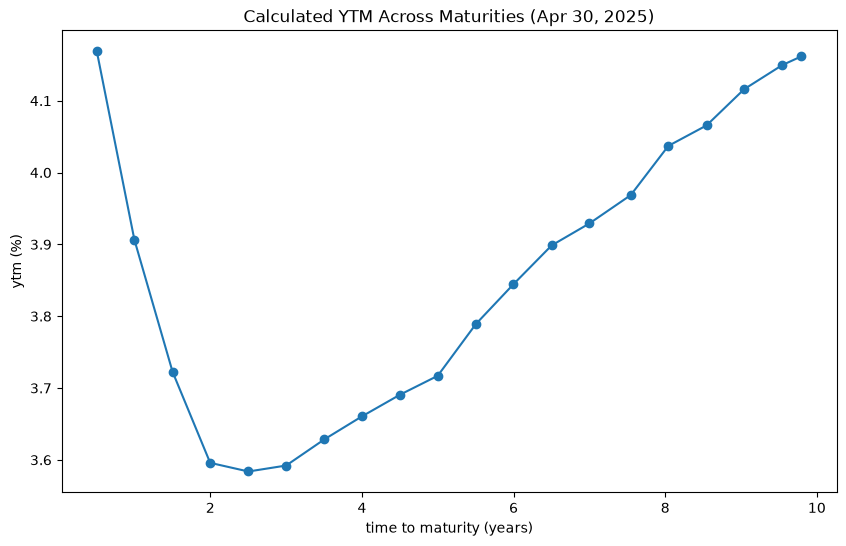

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(selected['ttm'], selected['calc ytm'] * 100, marker='o')
ax.set_title('Calculated YTM Across Maturities (Apr 30, 2025)')
ax.set_xlabel('time to maturity (years)')
ax.set_ylabel('ytm (%)')
plt.show()

***

# 2 Yields Across Maturities

### Data
Use the data in the `selected quotes` tab.

Focus on the nominal securities. 
* Exclude any row with `type` of `TIPS note` or `TIPS bond`.

In [5]:
# the selected quotes tab only has 20 notes, so this section uses the full
# quotes tab, which also has the bills and the TIPS
quotes = pd.read_excel(filepath, sheet_name='quotes').set_index('KYTREASNO')

nominal = quotes[~quotes['type'].isin(['TIPS note', 'TIPS bond'])].copy()
print(nominal['type'].value_counts())

type
note    242
bond    103
bill     51
Name: count, dtype: int64


### 2.1
Plot the time-to-maturity against the provided YTM.

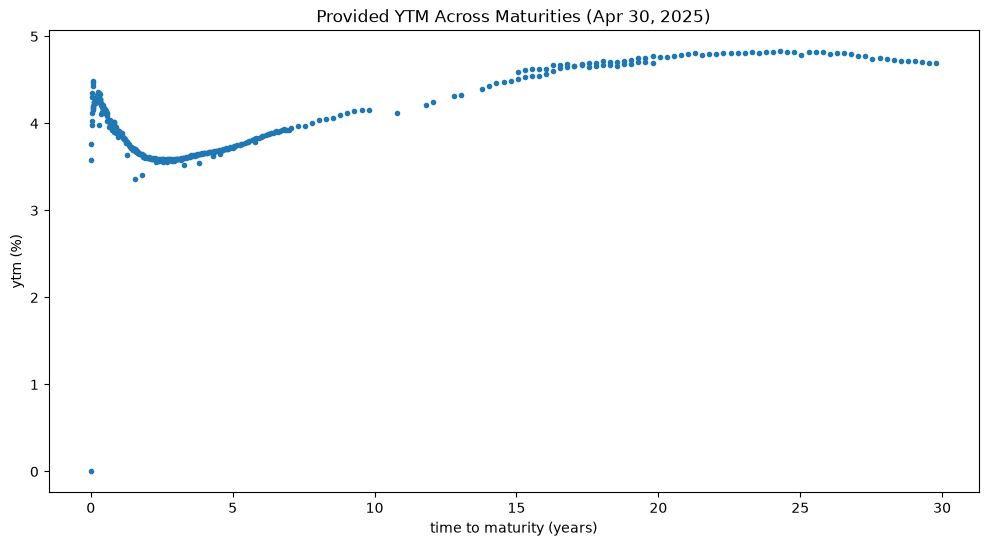

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(nominal['ttm'], nominal['ytm'] * 100, marker='o', linestyle='', markersize=3)
ax.set_title('Provided YTM Across Maturities (Apr 30, 2025)')
ax.set_xlabel('time to maturity (years)')
ax.set_ylabel('ytm (%)')
plt.show()

### 2.2

1. Calculate the YTM of each (nominal) bond issue in the data set.

1. Report how far your YTM calculation is from those reported in the data set.

1. Report your calculated YTM for the issues where the dataset does not provide a YTM.

In [7]:
# ytm for every nominal coupon issue (bills have no coupons, they are done in 2.3)
coupons = nominal[nominal['type'].isin(['note', 'bond'])].copy()
coupons['calc ytm'] = [
    solve_ytm(row['price'], max(round(2 * row['ttm']), 1) / 2, row['cpn rate'] / 100)
    for _, row in coupons.iterrows()
]

# distance from the provided ytm, in basis points
coupons['diff (bps)'] = (coupons['calc ytm'] - coupons['ytm']) * 1e4
print(coupons['diff (bps)'].abs().describe().round(2))

# the biggest gaps are the issues closest to maturity, where rounding
# the ttm to whole semiannual periods is roughest
tab = coupons[['ttm', 'cpn rate', 'price', 'ytm', 'calc ytm', 'diff (bps)']]
tab.reindex(coupons['diff (bps)'].abs().sort_values().index).tail().round(4)

count    345.00
mean      12.39
std       34.50
min        0.00
25%        0.35
50%        1.57
75%        8.54
max      347.72
Name: diff (bps), dtype: float64


,ttm,cpn rate,price,ytm,calc ytm,diff (bps)
KYTREASNO,,,,,,
207886,0.0411,2.750,99.9351,0.0435,0.0288,-146.4622
206859,0.0411,2.125,99.9115,0.0430,0.0230,-200.0171
207580,0.2519,0.250,98.9935,0.0431,0.0229,-202.5572
207560,0.1670,0.250,99.3426,0.0424,0.0158,-266.7092
207545,0.0849,0.250,99.6495,0.0443,0.0095,-347.7166


In [8]:
# the only issues without a provided ytm are the TIPS
tips = quotes[quotes['type'].isin(['TIPS note', 'TIPS bond'])].copy()
tips['calc ytm'] = [
    solve_ytm(row['price'], max(round(2 * row['ttm']), 1) / 2, row['cpn rate'] / 100)
    for _, row in tips.iterrows()
]

# these come out much lower than the nominal ytms because TIPS coupons are
# paid on an inflation adjusted principal, so these are real yields
tips[['type', 'maturity date', 'ttm', 'cpn rate', 'price', 'calc ytm']].round({'ttm': 4, 'price': 4, 'calc ytm': 4})

,type,maturity date,ttm,cpn rate,price,calc ytm
KYTREASNO,,,,,,
206878,TIPS note,2025-07-15,0.2081,0.375,99.9003,0.0057
207623,TIPS note,2025-10-15,0.4600,0.125,99.9577,0.0021
206941,TIPS note,2026-01-15,0.7118,0.625,99.9254,0.0077
206480,TIPS bond,2026-01-15,0.7118,2.000,100.8787,0.0024
207702,TIPS note,2026-04-15,0.9582,0.125,99.3717,0.0076
206999,TIPS note,2026-07-15,1.2074,0.125,99.7439,0.0038
207790,TIPS note,2026-10-15,1.4593,0.125,99.4773,0.0048
207056,TIPS note,2027-01-15,1.7112,0.375,99.3442,0.0082
206481,TIPS bond,2027-01-15,1.7112,2.375,102.7378,0.0054


### 2.3

For the Treasury bills, calculate the **discount yields**.

Identify the T-bills using `type`=`bill` or looking for `cpnrate` of 0.

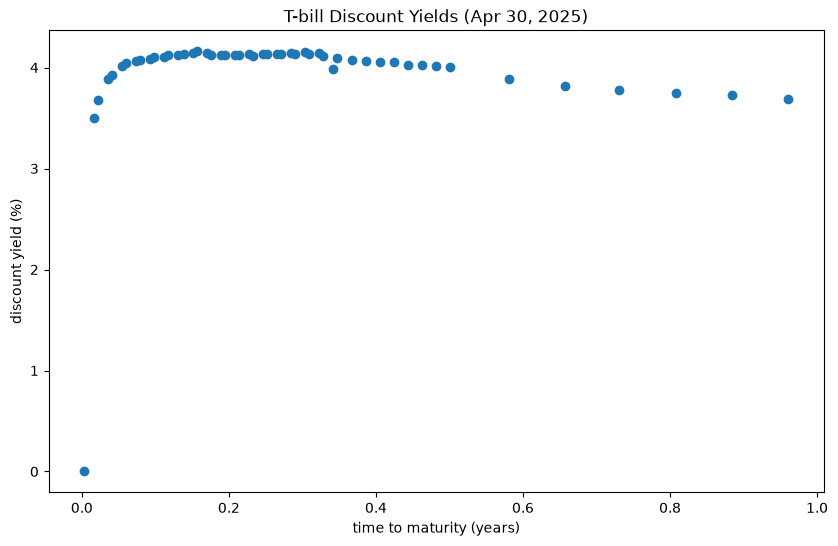

,maturity date,ttm,price,discount yield
KYTREASNO,,,,
208300,2025-05-01,0.0027,100.0000,0.0000
208327,2025-05-06,0.0164,99.9417,0.0350
208311,2025-05-08,0.0219,99.9183,0.0367
208336,2025-05-13,0.0356,99.8597,0.0389
208226,2025-05-15,0.0411,99.8363,0.0393
208337,2025-05-20,0.0548,99.7767,0.0402
208312,2025-05-22,0.0602,99.7528,0.0405
208338,2025-05-27,0.0739,99.6951,0.0407
208313,2025-05-29,0.0794,99.6722,0.0407


In [9]:
# discount yield: (F - p) / F * 360 / days to maturity
bills = nominal[nominal['type'] == 'bill'].copy()
days = (bills['maturity date'] - bills['quote date']).dt.days
bills['discount yield'] = (100 - bills['price']) / 100 * 360 / days

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bills['ttm'], bills['discount yield'] * 100, marker='o', linestyle='')
ax.set_title('T-bill Discount Yields (Apr 30, 2025)')
ax.set_xlabel('time to maturity (years)')
ax.set_ylabel('discount yield (%)')
plt.show()

bills[['maturity date', 'ttm', 'price', 'discount yield']].head(10).round({'ttm': 4, 'price': 4, 'discount yield': 4})